# Analiza sygnału EKG oraz zmienność rytmu serca (HRV)

W tym dokumencie prezentujemy analizę sygnału elektrokardiograficznego (EKG)
w dziedzinie czasu oraz częstotliwości.
Celem projektu jest zaprezentowanie klasycznych metod analizy sygnałów
stosowanych w przetwarzaniu sygnałów biomedycznych, takich jak filtracja,
detekcja szczytów, analiza statystyczna oraz analiza widmowa
oparta na transformacji Fouriera.

---

## 1. Wprowadzenie

Elektrokardiogram (EKG) jest sygnałem biomedycznym reprezentującym aktywność elektryczną serca
rejestrowaną na powierzchni ciała.
Z punktu widzenia przetwarzania sygnałów traktujemy EKG jako jednowymiarowy,
dyskretny sygnał czasowy zawierający powtarzalne zdarzenia (uderzenia serca)
oraz różnego rodzaju zakłócenia i szumy.

W tym projekcie:
- Wstępnie przetwarzamy sygnał EKG z wykorzystaniem filtracji cyfrowej
- Wykrywamy uderzenia serca na podstawie zespołów QRS
- Wyznaczamy odstępy RR oraz podstawowe miary zmienności rytmu serca (HRV)
- Analizujemy sygnał EKG oraz HRV w dziedzinie częstotliwości
  przy użyciu estymacji gęstości widmowej mocy

---

## 1.1 Podstawy teoretyczne i definicje

W tym projekcie wykorzystujemy pojęcia powszechnie stosowane
w analizie sygnałów elektrokardiograficznych.
Poniżej wprowadzamy krótkie definicje najważniejszych terminów
używanych w dalszej części dokumentu.

**Zespół QRS**  
Zespół QRS jest charakterystycznym fragmentem sygnału EKG
odpowiadającym depolaryzacji komór serca.
Charakteryzuje się dużą amplitudą oraz stromymi zboczami,
co czyni go najbardziej wyrazistym elementem sygnału EKG
i podstawą detekcji uderzeń serca.

**Załamek R**  
Załamek R jest najwyższym punktem zespołu QRS.
W analizie sygnałów EKG jest on wykorzystywany jako precyzyjny znacznik czasowy
pojedynczego uderzenia serca.

**Odstęp RR**  
Odstęp RR definiowany jest jako różnica czasowa pomiędzy kolejnymi załamkami R.
Sekwencja odstępów RR opisuje zmienność czasową pracy serca
i stanowi podstawę analizy zmienności rytmu serca.

**Zmienność rytmu serca (HRV)**  
Zmienność rytmu serca (HRV, ang. *Heart Rate Variability*)
opisuje zmiany długości kolejnych odstępów RR w czasie.
W ujęciu analizy sygnałów HRV traktowana jest jako sygnał pochodny,
który może być analizowany metodami statystycznymi
oraz w dziedzinie częstotliwości.

**Analiza w dziedzinie czasu**  
Analiza w dziedzinie czasu polega na badaniu wartości sygnału
oraz zdarzeń (np. uderzeń serca) bezpośrednio w funkcji czasu.
W kontekście EKG obejmuje ona detekcję załamków R
oraz wyznaczanie odstępów RR.

**Analiza w dziedzinie częstotliwości**  
Analiza w dziedzinie częstotliwości polega na badaniu składowych widmowych sygnału
i rozkładu energii w funkcji częstotliwości.
W projekcie wykorzystano estymację gęstości widmowej mocy
opartą na metodzie Welcha.

---

Zaczynamy od wczytania używanych bibliotek oraz ustawienia paru parametrów dotyczących wykresów.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import wfdb

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

---

## 2. Wczytanie danych i wstępna inspekcja

Wczytujemy nagranie EKG pochodzące z bazy danych *Normal Sinus Rhythm Database*
udostępnionej przez PhysioNet.
Repozytorium to jest powszechnie wykorzystywane w badaniach naukowych
oraz w celach dydaktycznych.

Na tym etapie odczytujemy podstawowe informacje o sygnale,
a następnie wybieramy krótki fragment nagrania,
który wykorzystujemy w dalszej analizie.

In [ ]:
record_name = "signal"

record = wfdb.rdrecord(record_name)

In [64]:
print("Częstotliwość próbkowania:", record.fs, "Hz")
print("Kształt sygnału:", record.p_signal.shape)
print("Nazwy sygnałów:", record.sig_name)

Częstotliwość próbkowania: 128 Hz
Kształt sygnału: (10866688, 2)
Nazwy sygnałów: ['ECG1', 'ECG2']


In [65]:
ecg = record.p_signal[:, 0]
fs = record.fs

In [66]:
duration_sec = len(ecg) / fs
print(f"Długość nagrania: {duration_sec/60:.2f} min")

Długość nagrania: 1414.93 min


Z całego nagrania wybrano pięciominutowy fragment sygnału,
który zostanie wykorzystany w dalszej analizie.

In [67]:
start_time = 0
duration = 5 * 60

start_sample = int(start_time * fs)
end_sample = int((start_time + duration) * fs)

ecg_segment = ecg[start_sample:end_sample]
time = np.arange(len(ecg_segment)) / fs

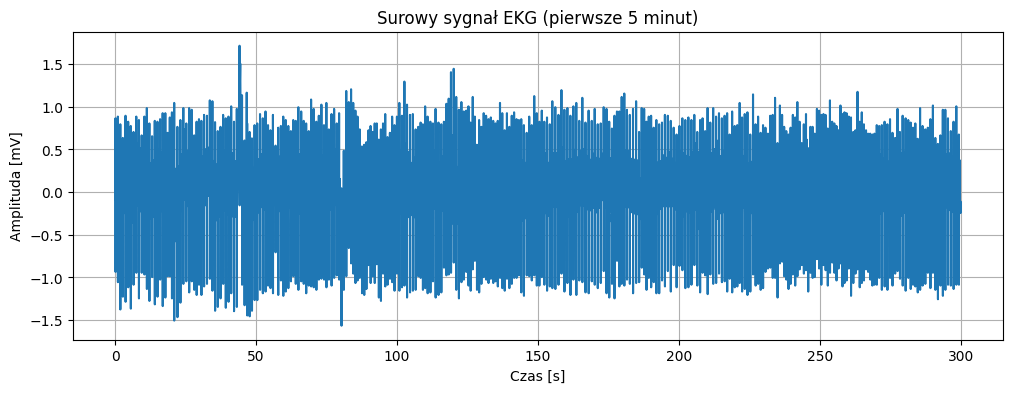

In [68]:
plt.figure()
plt.plot(time, ecg_segment)
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.title("Surowy sygnał EKG (pierwsze 5 minut)")
plt.show()

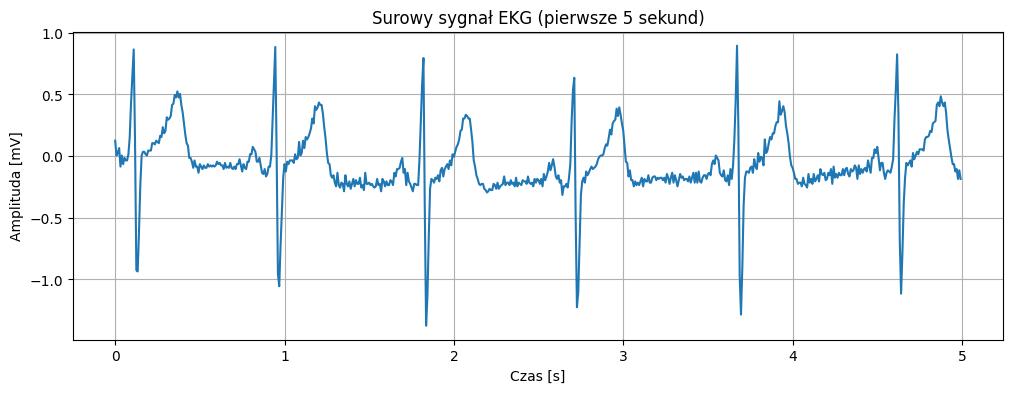

In [69]:
zoom_sec = 5
samples_zoom = int(zoom_sec * fs)

plt.figure()
plt.plot(time[:samples_zoom], ecg_segment[:samples_zoom])
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.title("Surowy sygnał EKG (pierwsze 5 sekund)")
plt.show()

---

## 3. Wstępne przetwarzanie sygnału

Surowe sygnały EKG zazwyczaj zawierają składowe niskoczęstotliwościowe,
szum mięśniowy oraz zakłócenia wysokoczęstotliwościowe.
W celu poprawy jakości sygnału oraz zwiększenia niezawodności
detekcji uderzeń serca stosujemy filtrację pasmowoprzepustową.

W projekcie wykorzystujemy filtr Butterwortha
o paśmie przepustowym od $0.5 \,\text{Hz}$ do $40 \,\text{Hz}$,
który pozwala zachować istotne składowe sygnału EKG,
w szczególności zespoły QRS,
jednocześnie tłumiąc niepożądane zakłócenia.

In [70]:
lowcut = 0.5
highcut = 40.0
order = 4

In [71]:
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

b, a = signal.butter(order, [low, high], btype='bandpass')

In [72]:
ecg_filtered = signal.filtfilt(b, a, ecg_segment)

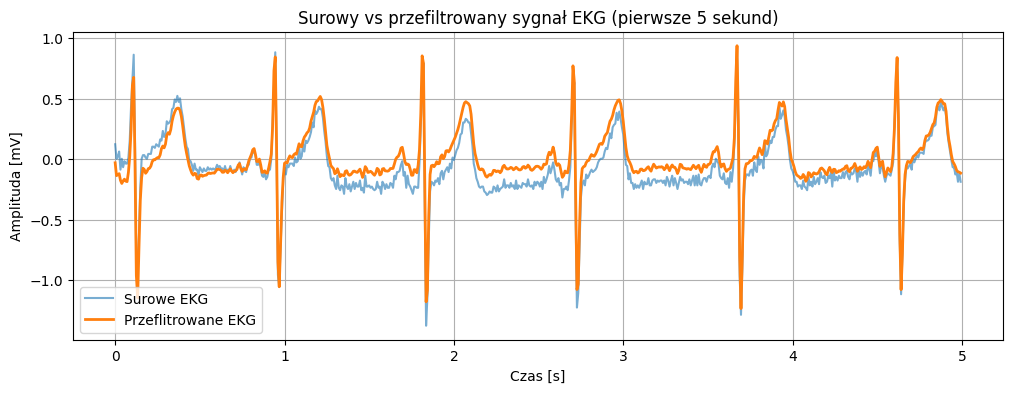

In [ ]:
plt.figure()
plt.plot(time[:samples_zoom], ecg_segment[:samples_zoom], label="Surowe EKG", alpha=0.6)
plt.plot(time[:samples_zoom], ecg_filtered[:samples_zoom], label="Przefiltrowane EKG", linewidth=2)
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.title("Surowy vs przefiltrowany sygnał EKG (pierwsze 5 sekund)")
plt.legend()
plt.show()

---

### Projekt filtru i jego charakterystyka częstotliwościowa

Charakterystykę częstotliwościową zaprojektowanego filtru analizujemy
w celu potwierdzenia, że pożądane pasmo częstotliwości jest zachowane,
a składowe spoza tego zakresu są skutecznie tłumione.

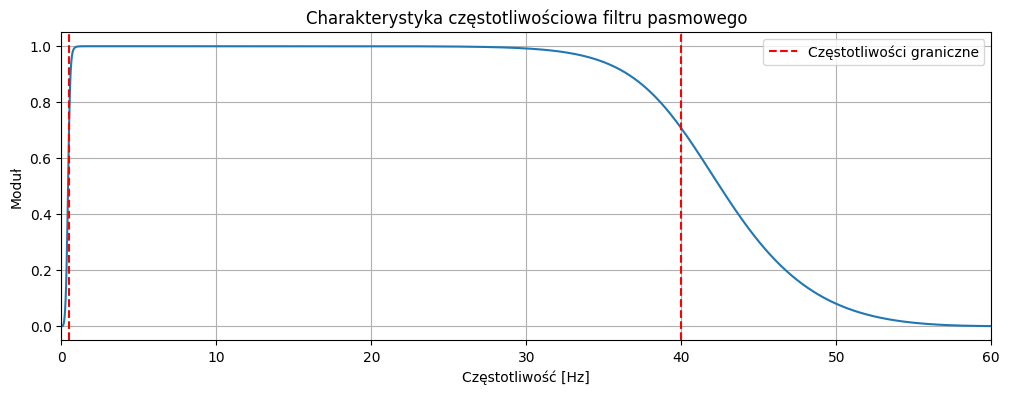

In [74]:
w, h = signal.freqz(b, a, worN=2048)
freqs = w * fs / (2 * np.pi)

plt.figure()
plt.plot(freqs, np.abs(h))
plt.axvline(lowcut, color='red', linestyle='--', label='Częstotliwości graniczne')
plt.axvline(highcut, color='red', linestyle='--')
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Moduł")
plt.title("Charakterystyka częstotliwościowa filtru pasmowego")
plt.legend()
plt.xlim(0, 60)
plt.show()

---

## 4. Analiza w dziedzinie czasu

W analizie w dziedzinie czasu koncentrujemy się na wykrywaniu
pojedynczych uderzeń serca oraz badaniu zmienności czasowej
odstępów pomiędzy nimi.
Uderzenia serca identyfikujemy poprzez detekcję załamków R,
odpowiadających zespołom QRS.

---

### Wykrywanie załamków R

Załamki R wykrywamy za pomocą algorytmu detekcji szczytów
z ograniczeniami na minimalną wysokość szczytu
oraz minimalną odległość pomiędzy kolejnymi wykryciami.
Parametry te dobieramy na podstawie fizjologicznych
granic częstości pracy serca.

In [75]:
min_rr_sec = 0.3
min_distance = int(min_rr_sec * fs)
peak_height = 0.5 * np.max(ecg_filtered)

In [76]:
r_peaks, properties = signal.find_peaks(
    ecg_filtered,
    height=peak_height,
    distance=min_distance
)

In [77]:
print("Ilość wykrytych załamków R:", len(r_peaks))

Ilość wykrytych załamków R: 331


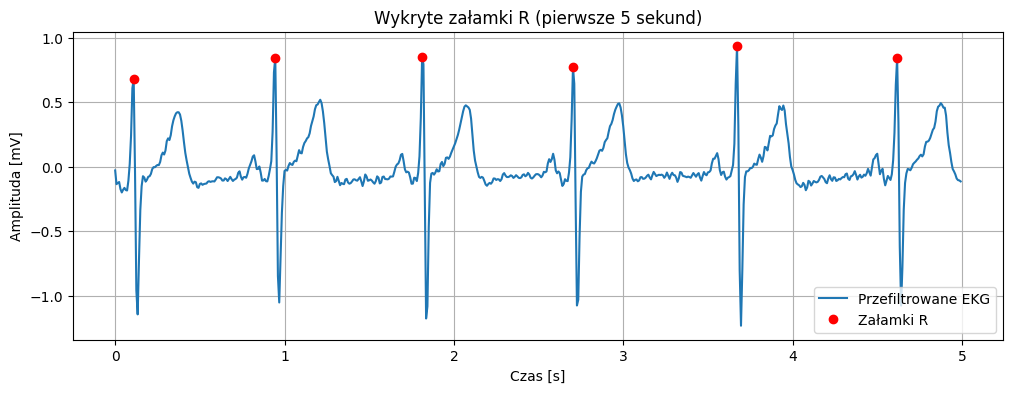

In [78]:
plt.figure()
plt.plot(time[:samples_zoom], ecg_filtered[:samples_zoom], label="Przefiltrowane EKG")
plt.plot(
    time[r_peaks[r_peaks < samples_zoom]],
    ecg_filtered[r_peaks[r_peaks < samples_zoom]],
    "ro",
    label="Załamki R"
)
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.title("Wykryte załamki R (pierwsze 5 sekund)")
plt.legend()
plt.show()

---

### Odstępy RR i zmienność rytmu serca

Na podstawie wykrytych załamków R wyznaczamy odstępy RR,
które stanowią podstawę analizy zmienności rytmu serca (HRV).

Następnie obliczamy podstawowe miary HRV w dziedzinie czasu:
- Średni odstęp RR
- SDNN (odchylenie standardowe odstępów RR)
- RMSSD (pierwiastek średniej kwadratowej różnic kolejnych odstępów RR)


In [79]:
r_times = r_peaks / fs
rr_intervals = np.diff(r_times)

In [80]:
print("Średni odstęp RR [s]:", np.mean(rr_intervals))
print("Przybliżone tętno [bpm]:", 60 / np.mean(rr_intervals))

Średni odstęp RR [s]: 0.9068418560606061
Przybliżone tętno [bpm]: 66.16368620284558


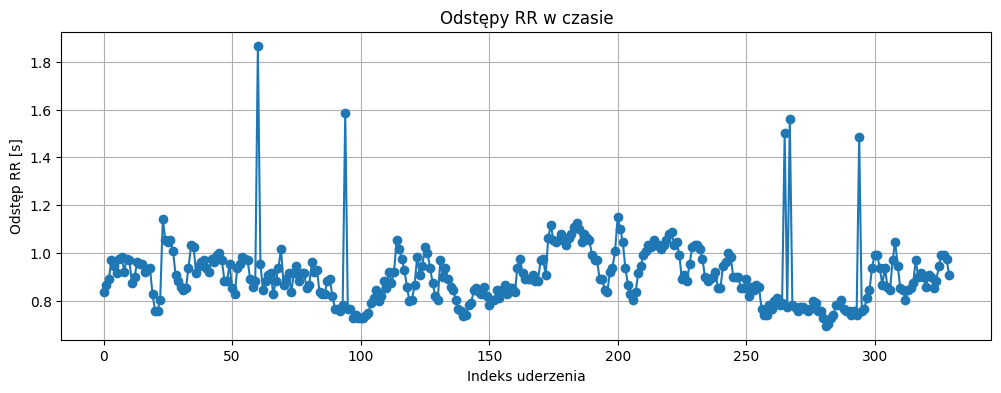

In [81]:
plt.figure()
plt.plot(rr_intervals, marker='o', linestyle='-')
plt.xlabel("Indeks uderzenia")
plt.ylabel("Odstęp RR [s]")
plt.title("Odstępy RR w czasie")
plt.show()

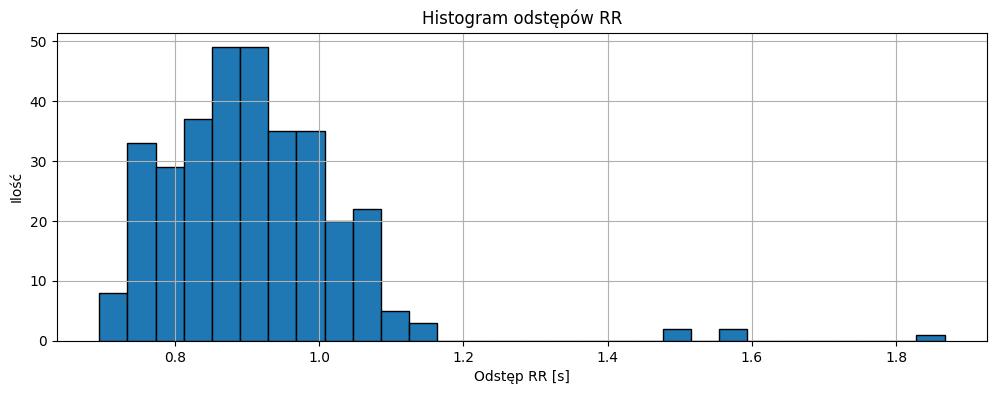

In [82]:
plt.figure()
plt.hist(rr_intervals, bins=30, edgecolor='black')
plt.xlabel("Odstęp RR [s]")
plt.ylabel("Ilość")
plt.title("Histogram odstępów RR")
plt.show()

In [ ]:
mean_rr = np.mean(rr_intervals)
sdnn = np.std(rr_intervals, ddof=1)
rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))

print(f"Średni odstęp RR: {mean_rr:.3f} s")
print(f"SDNN: {sdnn:.3f} s")
print(f"RMSSD: {rmssd:.3f} s")

Średni odstęp RR: 0.907 s
SDNN: 0.131 s
RMSSD: 0.150 s


---

### Usunięcie niewiarygodnych odstępów RR

W niektórych przypadkach błędy detekcji załamków R
prowadzą do sztucznie zawyżonych odstępów RR.
W celu ograniczenia ich wpływu na analizę HRV
usuwamy odstępy RR spoza fizjologicznie wiarygodnego zakresu
i ponownie analizujemy otrzymane wyniki.

In [84]:
rr_clean = rr_intervals[(rr_intervals > 0.4) & (rr_intervals < 1.3)]

In [85]:
print("Średni odstęp RR [s]:", np.mean(rr_clean))
print("Przybliżone tętno [bpm]:", 60 / np.mean(rr_clean))

Średni odstęp RR [s]: 0.8961778846153846
Przybliżone tętno [bpm]: 66.95099380381427


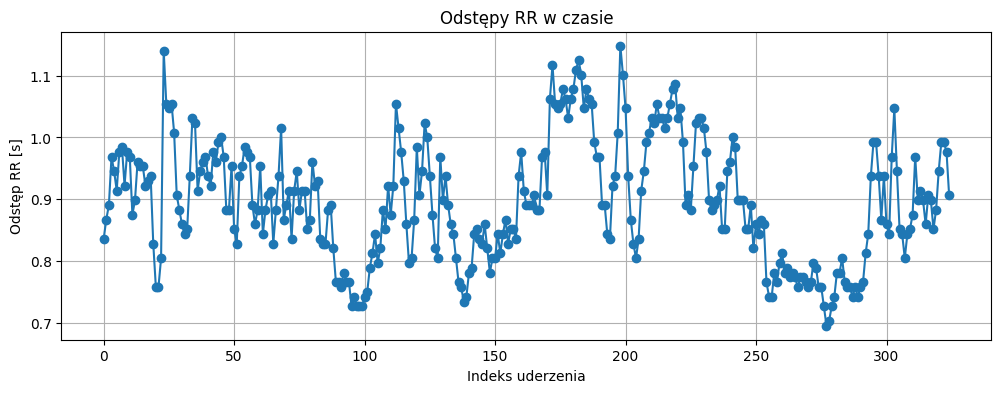

In [86]:
plt.figure()
plt.plot(rr_clean, marker='o', linestyle='-')
plt.xlabel("Indeks uderzenia")
plt.ylabel("Odstęp RR [s]")
plt.title("Odstępy RR w czasie")
plt.show()

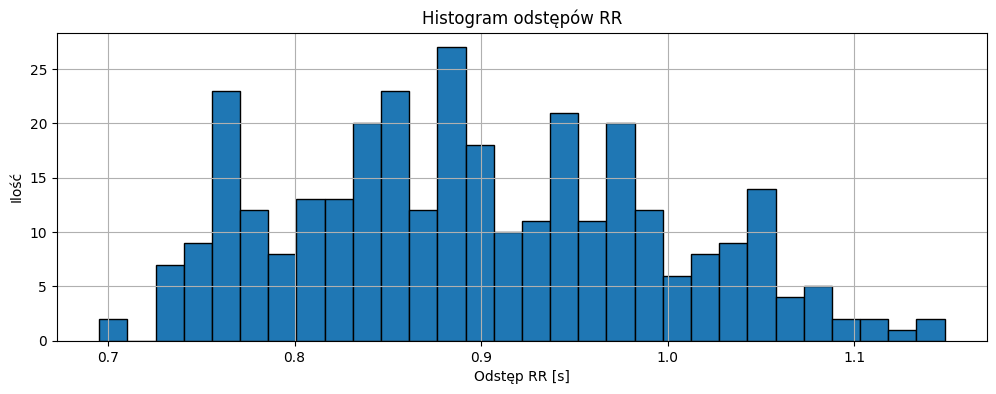

In [87]:
plt.figure()
plt.hist(rr_clean, bins=30, edgecolor='black')
plt.xlabel("Odstęp RR [s]")
plt.ylabel("Ilość")
plt.title("Histogram odstępów RR")
plt.show()

In [88]:
mean_rr = np.mean(rr_clean)
sdnn = np.std(rr_clean, ddof=1)
rmssd = np.sqrt(np.mean(np.diff(rr_clean) ** 2))

print(f"Średni odstęp RR: {mean_rr:.3f} s")
print(f"SDNN: {sdnn:.3f} s")
print(f"RMSSD: {rmssd:.3f} s")

Średni odstęp RR: 0.896 s
SDNN: 0.097 s
RMSSD: 0.053 s


---

## 5. Analiza w dziedzinie częstotliwości

W analizie w dziedzinie częstotliwości badamy rozkład energii sygnałów
w funkcji częstotliwości.
W projekcie analizujemy zarówno sygnał EKG,
jak i sygnał zmienności odstępów RR (HRV).

---

### Gęstość widmowa mocy sygnału EKG

Gęstość widmową mocy sygnału EKG estymujemy
z wykorzystaniem metody Welcha,
którą wybieramy w celu zmniejszenia wariancji estymacji widma
dla sygnałów o skończonej długości.
Porównujemy widma sygnału surowego oraz przefiltrowanego.

In [89]:
f_raw, psd_raw = signal.welch(ecg_segment, fs=fs, nperseg=2048)
f_filt, psd_filt = signal.welch(ecg_filtered, fs=fs, nperseg=2048)

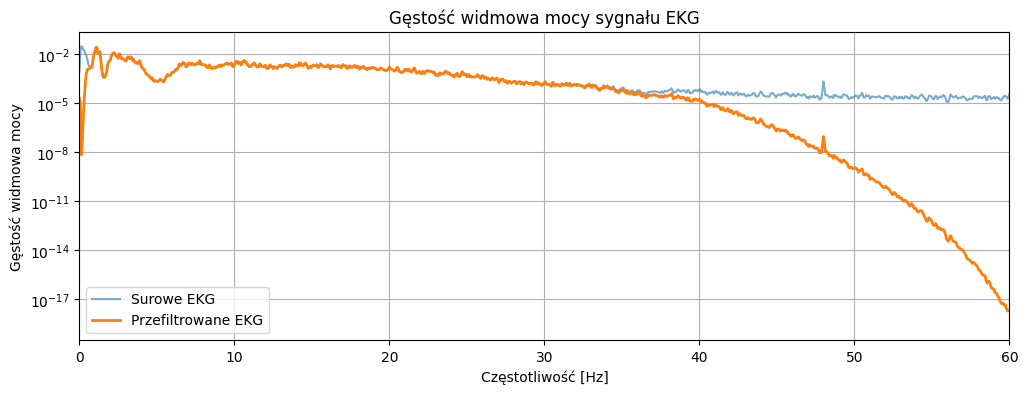

In [90]:
plt.figure()
plt.semilogy(f_raw, psd_raw, label="Surowe EKG", alpha=0.6)
plt.semilogy(f_filt, psd_filt, label="Przefiltrowane EKG", linewidth=2)
plt.xlim(0, 60)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Gęstość widmowa mocy")
plt.title("Gęstość widmowa mocy sygnału EKG")
plt.legend()
plt.show()

---

### Analiza widmowa zmienności rytmu serca

Ponieważ odstępy RR są nieregularnie próbkowane w czasie,
nie możemy analizować ich bezpośrednio za pomocą FFT.
Dlatego interpolujemy sekwencję RR do równomiernej siatki czasowej,
a następnie wyznaczamy gęstość widmową mocy sygnału HRV
z wykorzystaniem metody Welcha.

In [91]:
rr_times = np.cumsum(rr_clean)
rr_times -= rr_times[0]

In [92]:
fs_rr = 4.0
t_uniform = np.arange(0, rr_times[-1], 1/fs_rr)

rr_interp = np.interp(t_uniform, rr_times, rr_clean)

In [93]:
f_rr, psd_rr = signal.welch(rr_interp, fs=fs_rr, nperseg=256)

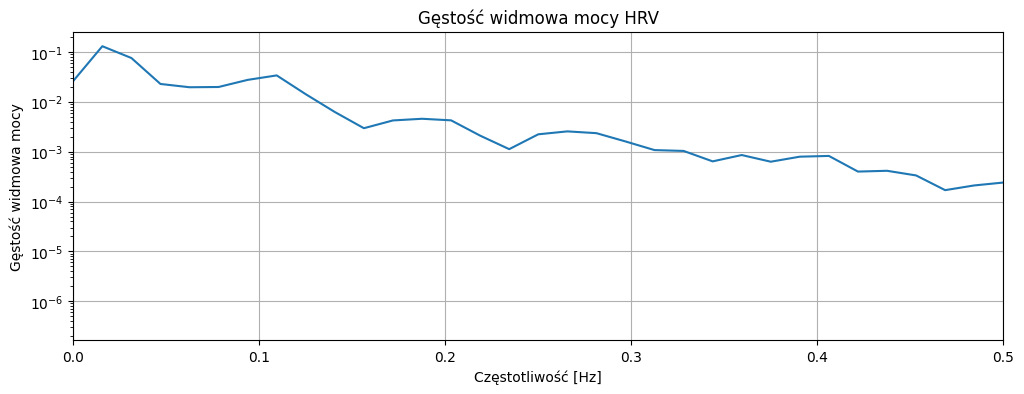

In [94]:
plt.figure()
plt.semilogy(f_rr, psd_rr)
plt.xlim(0, 0.5)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Gęstość widmowa mocy")
plt.title("Gęstość widmowa mocy HRV")
plt.show()

---

### Wpływ czyszczenia odstępów RR na widmo HRV

Aby ocenić wpływ czyszczenia odstępów RR,
porównujemy widma HRV przed i po usunięciu
mało prawdopodobnych wartości.
Pozwala to zaobserwować wpływ błędów detekcji
na estymację widma.

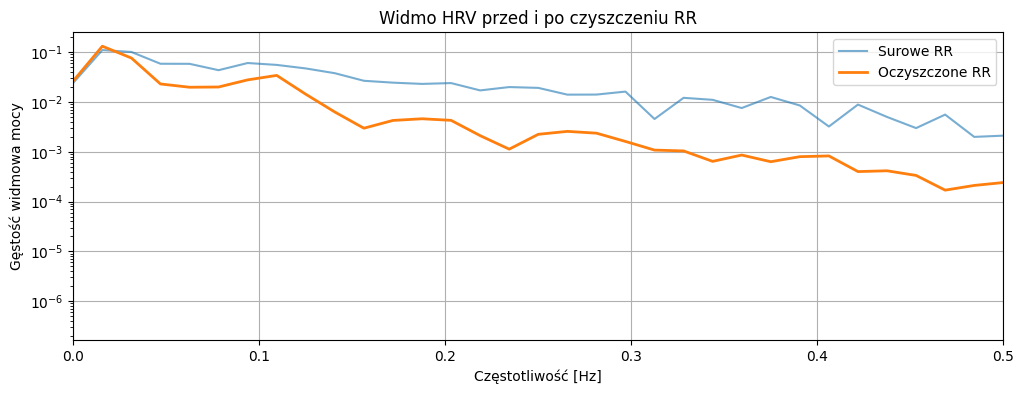

In [95]:
rr_times_raw = np.cumsum(rr_intervals)
rr_times_raw -= rr_times_raw[0]

t_uniform_raw = np.arange(0, rr_times_raw[-1], 1/fs_rr)
rr_interp_raw = np.interp(t_uniform_raw, rr_times_raw, rr_intervals)

f_rr_raw, psd_rr_raw = signal.welch(rr_interp_raw, fs=fs_rr, nperseg=256)

plt.figure()
plt.semilogy(f_rr_raw, psd_rr_raw, label="Surowe RR", alpha=0.6)
plt.semilogy(f_rr, psd_rr, label="Oczyszczone RR", linewidth=2)
plt.xlim(0, 0.5)
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Gęstość widmowa mocy")
plt.title("Widmo HRV przed i po czyszczeniu RR")
plt.legend()
plt.show()

---

## 6. Wnioski

W niniejszym projekcie przeanalizowaliśmy sygnał EKG
z wykorzystaniem klasycznych metod analizy sygnałów.
Stosując filtrację cyfrową poprawiliśmy jakość sygnału
i uzyskaliśmy wiarygodną detekcję uderzeń serca.

Analizując sygnał w dziedzinie czasu
wyznaczyliśmy istotne miary zmienności rytmu serca,
natomiast analiza w dziedzinie częstotliwości
ujawniła charakterystyczne własności widmowe
sygnału EKG oraz HRV,
zgodne z rytmem zatokowym.